# Decision Transformer — 序列建模的强化学习实验

验证 `decision-transformer.tex` 中的核心结论：

1. **RTG 条件化 = 指挥棒**：把期望回报（return-to-go）作为输入，DT 在数据覆盖区内按目标兑现回报；去掉 RTG 输入，模型退化为行为克隆（BC），回报无法指定；目标超出数据最优时崩溃（OOD 外推）；
2. **数据质量天花板**：random / medium / expert 三档数据上，DT 与 BC 的评估回报都钉在数据水平附近——DT 是「回放」不是「改进」；
3. **拼接失败**：格子世界中最优路径需要组合两条次优轨迹的前后半段（stitching）；离线 Q-learning 能拼出 14 步最优路径，DT 条件在最优回报上反而失效——它检索见过的轨迹，不组合未见过的。

任务：CartPole-v1（图 1/2）+ 确定性格子世界（图 3）。模型是与各章同构的小型因果 Transformer（约 12 万参数）。离线数据由第 4 章的 DQN 在不同训练阶段/不同探索强度下采集——与第 9 章 medium 数据集同一配方。

输出图：
- `fig1_rtg_conditioning.pdf`
- `fig2_data_quality.pdf`
- `fig3_stitching.pdf`

预计运行时间：GPU 约 45–60 分钟；CPU 需数小时，建议 GPU（3 seeds）。

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from collections import deque
import random

matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

BLUE  = '#2166AC'
RED   = '#D6604D'
GREEN = '#4DAC26'
GRAY  = '#808080'
FIGSIZE = (7.2, 4.8)
OUTDIR  = '.'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

SEEDS      = (42, 43, 44)
CONTEXT_K  = 16      # DT 上下文长度（token 数）
DT_STEPS   = 2500    # 每次训练的梯度步数
DT_BATCH   = 128
DT_LR      = 3e-4
EVAL_EPS   = 15      # 每个评估目标的 episode 数

# 格子世界（图 3）
GW_SIZE    = 8
GW_START   = 56      # (7, 0)：左下角
GW_GOAL    = 7       # (0, 7)：右上角
GW_EPISODES = 400
GW_MIN_LEN = 16      # 数据中最好的轨迹长度（最优路径 14 步从未出现）


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)


print(f'Device: {DEVICE}')

Device: cuda


In [2]:
try:
    import gymnasium as gym
    def make_env(name, seed=None):
        env = gym.make(name)
        if seed is not None and hasattr(env.action_space, 'seed'):
            env.action_space.seed(seed)
        return env
    def reset_env(env, seed=None):
        obs, _ = env.reset(seed=seed); return obs
    def step_env(env, action):
        obs, r, ter, tru, _ = env.step(action); return obs, r, ter, ter or tru
    print('Using gymnasium')
except ImportError:
    import gym
    def make_env(name, seed=None):
        env = gym.make(name)
        if seed is not None and hasattr(env.action_space, 'seed'):
            env.action_space.seed(seed)
        return env
    def reset_env(env, seed=None):
        if seed is not None: env.seed(seed)
        return env.reset()
    def step_env(env, action):
        obs, r, done, _ = env.step(action); return obs, r, done, done
    print('Using gym')
# episode_done resets episodes; terminated alone masks value bootstrapping.

Using gymnasium


In [3]:
# ── 数据生成：第 4 章的 DQN + 快照 ──────────────────────────────

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),   nn.ReLU(),
            nn.Linear(hidden, action_dim))

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, terminated):
        self.buffer.append((s, a, r, ns, terminated))

    def sample(self, n):
        batch = random.sample(self.buffer, n)
        s, a, r, ns, terminated = zip(*batch)
        return (np.array(s, np.float32), np.array(a, np.int64),
                np.array(r, np.float32), np.array(ns, np.float32), np.array(terminated, np.float32))

    def __len__(self):
        return len(self.buffer)


def train_dqn_snapshots(seed, total_episodes=350, snapshots=(30, 80, 150, 250, 350)):
    """训练一个 DQN，过程中保存快照——不同阶段的快照给出不同质量的行为策略。"""
    set_seed(seed)
    env = make_env('CartPole-v1', seed=seed)
    q, target = QNetwork(4, 2).to(DEVICE), QNetwork(4, 2).to(DEVICE)
    target.load_state_dict(q.state_dict()); target.eval()
    opt = torch.optim.Adam(q.parameters(), lr=3e-4)
    buf = ReplayBuffer(20000)
    eps, steps = 1.0, 0
    snaps = {}
    for ep in range(total_episodes):
        s, episode_done = reset_env(env, seed=seed * 1000 + ep), False
        while not episode_done:
            if random.random() < eps:
                a = env.action_space.sample()
            else:
                with torch.no_grad():
                    a = int(q(torch.tensor(s, dtype=torch.float32,
                                           device=DEVICE).unsqueeze(0)).argmax(dim=1))
            ns, r, terminated, episode_done = step_env(env, a)
            buf.push(s, a, r, ns, float(terminated))
            s = ns; steps += 1
            if len(buf) >= 500:
                s_b, a_b, r_b, ns_b, terminated_b = buf.sample(64)
                s_t = torch.tensor(s_b, device=DEVICE); a_t = torch.tensor(a_b, device=DEVICE)
                r_t = torch.tensor(r_b, device=DEVICE); ns_t = torch.tensor(ns_b, device=DEVICE)
                terminated_t = torch.tensor(terminated_b, device=DEVICE)
                curr = q(s_t).gather(1, a_t.unsqueeze(1)).squeeze(1)
                with torch.no_grad():
                    y = r_t + 0.99 * target(ns_t).max(dim=1)[0] * (1 - terminated_t)
                loss = F.mse_loss(curr, y)
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(q.parameters(), 1.0); opt.step()
                if steps % 100 == 0:
                    target.load_state_dict(q.state_dict())
        eps = max(0.05, eps * 0.995)
        if (ep + 1) in snapshots:
            snaps[ep + 1] = {k: v.clone() for k, v in q.state_dict().items()}
    env.close()
    return snaps, q.state_dict()


@torch.no_grad()
def collect(qstate, n_episodes, eps, seed):
    """用（快照）策略 + ε 探索采集离线轨迹。eps=1 即纯随机策略。"""
    set_seed(seed)
    env = make_env('CartPole-v1', seed=seed)
    if qstate is None:
        net = None
    else:
        net = QNetwork(4, 2).to(DEVICE); net.load_state_dict(qstate); net.eval()
    episodes = []
    for ep in range(n_episodes):
        s, episode_done = reset_env(env, seed=seed * 10000 + ep), False
        states, actions, rewards = [], [], []
        while not episode_done:
            if random.random() < eps or net is None:
                a = env.action_space.sample()
            else:
                a = int(net(torch.tensor(s, dtype=torch.float32,
                                         device=DEVICE).unsqueeze(0)).argmax(dim=1))
            ns, r, _, episode_done = step_env(env, a)
            states.append(s); actions.append(a); rewards.append(r); s = ns
        episodes.append({'states': np.array(states, np.float32),
                         'actions': actions, 'rewards': rewards})
    env.close()
    return episodes


def summarize(name, episodes):
    rets = [sum(e['rewards']) for e in episodes]
    print(f'  {name:<8s}: {len(rets)} eps | return mean {np.mean(rets):6.1f} '
          f'| min {np.min(rets):4.0f} | max {np.max(rets):4.0f}')


def build_datasets(seed):
    """与第 9 章 medium 数据集同一配方：DQN 快照 + ε 探索，按质量分档。"""
    snaps, final = train_dqn_snapshots(seed)
    data = {
        'random': collect(None, 60, 1.0, seed + 1),
        'medium': collect(snaps[80], 300, 0.3, seed + 2),
        'expert': collect(final, 300, 0.05, seed + 3),
    }
    data['mixed'] = (data['random']
                     + collect(snaps[30],  60, 0.3,  seed + 4)
                     + collect(snaps[150], 60, 0.2,  seed + 5)
                     + collect(snaps[250], 60, 0.1,  seed + 6)
                     + collect(final,      60, 0.05, seed + 7))
    for k in ('random', 'medium', 'expert', 'mixed'):
        summarize(k, data[k])
    return data

print('Data-generation utilities ready.')

Data-generation utilities ready.


In [4]:
# ── Decision Transformer 与训练/评估 ────────────────────────────

class DecisionTransformer(nn.Module):
    """RTG 条件的因果 Transformer：第 t 个 token 编码 (R̂_t, s_t, a_{t-1})，预测 a_t。"""

    def __init__(self, state_dim, n_actions, d_model=64, n_layers=2, n_heads=4, context=16):
        super().__init__()
        self.embed_rtg    = nn.Linear(1, d_model)
        self.embed_state  = nn.Linear(state_dim, d_model)
        self.embed_action = nn.Embedding(n_actions + 1, d_model)   # 末位是 null 动作
        self.pos = nn.Embedding(context, d_model)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, 128, batch_first=True,
                                           dropout=0.0, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, n_layers, enable_nested_tensor=False)
        self.head = nn.Linear(d_model, n_actions)
        mask = torch.triu(torch.full((context, context), float('-inf')), 1)
        self.register_buffer('mask', mask)

    def forward(self, rtg, states, prev_a, pad_mask):
        # rtg (B,K) float | states (B,K,ds) | prev_a (B,K) long（pad 处为 null）| pad_mask (B,K) bool
        h = (self.embed_rtg(rtg.unsqueeze(-1)) + self.embed_state(states)
             + self.embed_action(prev_a)
             + self.pos(torch.arange(rtg.size(1), device=rtg.device)))
        h = self.encoder(h, mask=self.mask, src_key_padding_mask=~pad_mask)
        return self.head(h)


class TrajWindow:
    """离线轨迹 → (R̂, s, a_prev) 右对齐窗口；状态标准化、RTG 按数据最大回报缩放。"""

    def __init__(self, episodes, n_actions, context=16):
        self.K = context
        self.n_actions = n_actions
        states = np.concatenate([e['states'] for e in episodes])
        self.s_mean = states.mean(0)
        self.s_std = states.std(0) + 1e-6
        self.rtg_scale = max(1.0, max(sum(e['rewards']) for e in episodes))
        self.state_dim = states.shape[1]
        self.trajs = []
        for e in episodes:
            rtg = np.cumsum(np.array(e['rewards'])[::-1])[::-1].astype(np.float32)  # γ=1 sum-to-go
            self.trajs.append(((e['states'] - self.s_mean) / self.s_std, e['actions'], rtg))

    def sample_batch(self, batch, rng):
        K, ds, na = self.K, self.state_dim, self.n_actions
        rtg_b = np.zeros((batch, K), np.float32)
        s_b   = np.zeros((batch, K, ds), np.float32)
        pa_b  = np.full((batch, K), na, np.int64)
        tgt_b = np.zeros((batch, K), np.int64)
        m_b   = np.zeros((batch, K), bool)
        for b in range(batch):
            sn, acts, rtg = self.trajs[int(rng.integers(len(self.trajs)))]
            T = len(acts)
            j = int(rng.integers(0, T))
            L = min(K, T - j)                      # 真实 token 右对齐放在 [K-L, K)
            s_b[b, K-L:]   = sn[j:j+L]
            rtg_b[b, K-L:] = rtg[j:j+L] / self.rtg_scale
            tgt_b[b, K-L:] = acts[j:j+L]
            m_b[b, K-L:]   = True
            pa_b[b, K-L]   = na if j == 0 else acts[j-1]
            if L > 1:
                pa_b[b, K-L+1:] = acts[j:j+L-1]
        return (torch.tensor(rtg_b, device=DEVICE), torch.tensor(s_b, device=DEVICE),
                torch.tensor(pa_b, device=DEVICE), torch.tensor(tgt_b, device=DEVICE),
                torch.tensor(m_b, device=DEVICE))


def train_dt(episodes, n_actions, seed, use_rtg=True, steps=DT_STEPS,
             batch=DT_BATCH, lr=DT_LR, context=CONTEXT_K):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    win = TrajWindow(episodes, n_actions, context)
    model = DecisionTransformer(win.state_dim, n_actions, context=context).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for it in range(steps):
        rtg, s, pa, tgt, m = win.sample_batch(batch, rng)
        if not use_rtg:
            rtg = torch.zeros_like(rtg)
        logits = model(rtg, s, pa, m)
        loss = F.cross_entropy(logits[m], tgt[m])
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        if (it + 1) % 500 == 0:
            losses.append(loss.item())
    return model, win


@torch.no_grad()
def evaluate_dt(model, win, n_actions, target, use_rtg=True,
                n_episodes=EVAL_EPS, seed=0, max_steps=500):
    """在线评估：初始 R̂ = target，每步 R̂ ← R̂ − r（γ=1），贪心选动作。"""
    env = make_env('CartPole-v1', seed=seed)
    K = win.K
    returns = []
    for ep in range(n_episodes):
        s = reset_env(env, seed=seed * 1000 + ep)
        rtg, episode_done, total = float(target), False, 0.0
        ctx_s, ctx_pa, ctx_rtg = [], [], []
        prev_a = n_actions
        while not episode_done:
            ctx_s.append((np.asarray(s) - win.s_mean) / win.s_std)
            ctx_pa.append(prev_a)
            ctx_rtg.append(rtg / win.rtg_scale if use_rtg else 0.0)
            L = len(ctx_s); take = min(L, K); start = K - take
            rtgW = torch.zeros((1, K), device=DEVICE)
            sW = torch.zeros((1, K, win.state_dim), device=DEVICE)
            paW = torch.full((1, K), n_actions, dtype=torch.long, device=DEVICE)
            mW = torch.zeros((1, K), dtype=torch.bool, device=DEVICE)
            rtgW[0, start:] = torch.tensor(ctx_rtg[-take:], device=DEVICE)
            sW[0, start:] = torch.tensor(np.array(ctx_s[-take:]), dtype=torch.float32, device=DEVICE)
            paW[0, start:] = torch.tensor(ctx_pa[-take:], device=DEVICE)
            mW[0, start:] = True
            a = int(model(rtgW, sW, paW, mW)[0, -1].argmax())
            ns, r, _, episode_done = step_env(env, a)
            total += r; rtg -= r; prev_a = a; s = ns
        returns.append(total)
    env.close()
    return float(np.mean(returns)), float(np.std(returns))

print('DecisionTransformer ready.')

DecisionTransformer ready.


In [5]:
# ── 格子世界（图 3）：拼接失败的舞台 ────────────────────────────

def gw_step(s, a):
    row, col = divmod(s, GW_SIZE)
    if   a == 0: row = max(0, row - 1)             # up
    elif a == 1: row = min(GW_SIZE - 1, row + 1)   # down
    elif a == 2: col = max(0, col - 1)             # left
    else:        col = min(GW_SIZE - 1, col + 1)   # right
    s2 = row * GW_SIZE + col
    return s2, -1.0, s2 == GW_GOAL


def gw_gen_episode(rng, min_len=GW_MIN_LEN, cap=60):
    """行为策略：85% 向上/向右赶路，15% 向下/向左绕路；拒绝短于 min_len 的轨迹。"""
    while True:
        s = GW_START
        ss, aa, rr = [], [], []
        done = False
        for _ in range(cap):
            if rng.random() < 0.15:
                a = int(rng.choice([1, 2]))
            else:
                a = int(rng.choice([0, 3]))
            s2, r, done = gw_step(s, a)
            ss.append(s); aa.append(a); rr.append(r); s = s2
            if done:
                break
        if done and len(aa) >= min_len:
            return {'states': np.array(ss), 'actions': aa, 'rewards': rr}


def gw_to_dt(episodes):
    out = []
    for e in episodes:
        rc = np.array([[(s // GW_SIZE) / 7.0, (s % GW_SIZE) / 7.0] for s in e['states']],
                      np.float32)
        out.append({'states': rc, 'actions': e['actions'], 'rewards': e['rewards']})
    return out


def gw_q_learning(episodes, sweeps=400, alpha=0.5, gamma=1.0):
    """表格型离线 Q-learning：在数据转移上反复扫描，无探索、无模型。"""
    # 悲观初始化 + 只信数据访问过的动作：负奖励环境里 Q=0 的未访问动作会被 argmax 误选
    Q = np.full((GW_SIZE * GW_SIZE, 4), -100.0)
    visited = np.zeros((GW_SIZE * GW_SIZE, 4), bool)
    trans = []
    for e in episodes:
        for t in range(len(e['actions'])):
            s = int(e['states'][t]); a = int(e['actions'][t])
            s2, r, done = gw_step(s, a)
            trans.append((s, a, r, s2, done))
            visited[s, a] = True
    for _ in range(sweeps):
        for s, a, r, s2, done in trans:
            if done:
                tgt = r
            else:
                tgt = r + gamma * Q[s2][visited[s2]].max()
            Q[s, a] += alpha * (tgt - Q[s, a])
    s, path = GW_START, [GW_START]
    for _ in range(80):
        a = int(np.argmax(np.where(visited[s], Q[s], -1e6)))
        s, _, done = gw_step(s, a)
        path.append(s)
        if done:
            break
    return Q, path


@torch.no_grad()
def gw_eval_dt(model, win, n_actions, target_len, n_episodes=30, cap=60):
    """条件在目标长度 target_len 上评估 DT；返回平均路径长度与未达终点数。"""
    lengths, failures = [], 0
    for ep in range(n_episodes):
        rng = np.random.default_rng(1000 * ep + target_len)
        s, rtg, prev_a = GW_START, -float(target_len), n_actions
        ctx_s, ctx_pa, ctx_rtg = [], [], []
        reached = False
        for t in range(cap):
            ctx_s.append(np.array([(s // GW_SIZE) / 7.0, (s % GW_SIZE) / 7.0], np.float32))
            ctx_pa.append(prev_a)
            ctx_rtg.append(rtg / win.rtg_scale)
            K = win.K; L = len(ctx_s); take = min(L, K); start = K - take
            rtgW = torch.zeros((1, K), device=DEVICE)
            sW = torch.zeros((1, K, 2), device=DEVICE)
            paW = torch.full((1, K), n_actions, dtype=torch.long, device=DEVICE)
            mW = torch.zeros((1, K), dtype=torch.bool, device=DEVICE)
            rtgW[0, start:] = torch.tensor(ctx_rtg[-take:], device=DEVICE)
            sW[0, start:] = torch.tensor(np.array(ctx_s[-take:]), device=DEVICE)
            paW[0, start:] = torch.tensor(ctx_pa[-take:], device=DEVICE)
            mW[0, start:] = True
            a = int(model(rtgW, sW, paW, mW)[0, -1].argmax())
            s2, r, done = gw_step(s, a)
            rtg -= r; prev_a = a; s = s2
            if done:
                lengths.append(t + 1); reached = True
                break
        if not reached:
            lengths.append(cap); failures += 1
    return float(np.mean(lengths)), float(np.std(lengths)), failures

print('Gridworld utilities ready.')

Gridworld utilities ready.


---
## Figure 1 — RTG 条件化：回报成为指令

左图：混合质量数据（random → expert 全谱）上训练的 DT，评估时把期望回报 $R̂_1$ 从 20 扫到 500——评估回报紧贴目标（虚线为 $y=x$），阴影为数据回报的覆盖范围。作为对照，去掉 RTG 输入训练的同一模型（即序列 BC）无论「想要多少分」，回报都钉在一个固定水平——**没有 RTG，回报无法指定**。右图：目标超出数据最优（>500）后，DT 无法兑现甚至崩溃——条件化只在数据支撑区内有效（3 seeds，mean $\pm$ std）。

In [6]:
print('=== Experiment 1: RTG conditioning vs no-RTG (BC) on mixed data ===')
runs = {}
for seed in SEEDS:
    print(f'-- seed {seed}: building datasets (DQN + snapshots) --')
    runs[seed] = {'data': build_datasets(seed)}
    d = runs[seed]['data']
    set_seed(seed)
    runs[seed]['dt'],  runs[seed]['win'] = train_dt(d['mixed'], 2, seed, use_rtg=True)
    runs[seed]['bc'], _                 = train_dt(d['mixed'], 2, seed + 100, use_rtg=False)
    print(f'   trained DT (mixed) and no-RTG BC')

TARGETS = [20, 50, 100, 200, 300, 400, 500]
dt_curve = []
for seed in SEEDS:
    r, w = runs[seed]['dt'], runs[seed]['win']
    dt_curve.append([evaluate_dt(r, w, 2, t, seed=seed)[0] for t in TARGETS])
dt_curve = np.array(dt_curve)

bc_curve = []
for seed in SEEDS:
    r, w = runs[seed]['bc'], runs[seed]['win']
    bc_curve.append([evaluate_dt(r, w, 2, t, seed=seed + 50, use_rtg=False)[0] for t in TARGETS])
bc_curve = np.array(bc_curve)

OOD_TARGETS = [400, 500, 600, 700, 800, 1000]
ood_curve = []
for seed in SEEDS:
    r, w = runs[seed]['dt'], runs[seed]['win']
    ood_curve.append([evaluate_dt(r, w, 2, t, seed=seed + 200)[0] for t in OOD_TARGETS])
ood_curve = np.array(ood_curve)

for i, t in enumerate(TARGETS):
    print(f'  target {t:4d}: DT {dt_curve[:, i].mean():6.1f} ± {dt_curve[:, i].std():5.1f}')
print(f'  no-RTG (BC) mean over targets: {bc_curve.mean():.1f}')
for i, t in enumerate(OOD_TARGETS):
    print(f'  OOD target {t:4d}: DT {ood_curve[:, i].mean():6.1f} ± {ood_curve[:, i].std():5.1f}')

data_min = min(sum(e['rewards']) for e in runs[SEEDS[0]]['data']['mixed'])
data_max = max(sum(e['rewards']) for e in runs[SEEDS[0]]['data']['mixed'])

=== Experiment 1: RTG conditioning vs no-RTG (BC) on mixed data ===
-- seed 42: building datasets (DQN + snapshots) --


  random  : 60 eps | return mean   20.2 | min   10 | max   51
  medium  : 300 eps | return mean  200.9 | min   19 | max  421
  expert  : 300 eps | return mean  500.0 | min  500 | max  500
  mixed   : 300 eps | return mean  177.7 | min   10 | max  500


   trained DT (mixed) and no-RTG BC
-- seed 43: building datasets (DQN + snapshots) --


  random  : 60 eps | return mean   23.2 | min   10 | max   75
  medium  : 300 eps | return mean  210.0 | min   45 | max  451
  expert  : 300 eps | return mean  102.4 | min   12 | max  116
  mixed   : 300 eps | return mean  165.6 | min    8 | max  500


   trained DT (mixed) and no-RTG BC
-- seed 44: building datasets (DQN + snapshots) --


  random  : 60 eps | return mean   23.2 | min    9 | max  101
  medium  : 300 eps | return mean  222.5 | min   11 | max  500
  expert  : 300 eps | return mean  481.8 | min   12 | max  500
  mixed   : 300 eps | return mean  181.3 | min    8 | max  500


   trained DT (mixed) and no-RTG BC


  target   20: DT    9.4 ±   0.4
  target   50: DT    9.7 ±   0.4
  target  100: DT   33.1 ±  29.6
  target  200: DT  209.7 ±  23.0
  target  300: DT  285.6 ±  11.7
  target  400: DT  322.1 ±  32.7
  target  500: DT  334.5 ±  85.3
  no-RTG (BC) mean over targets: 9.5
  OOD target  400: DT  315.2 ±  14.7
  OOD target  500: DT  342.0 ±  43.3
  OOD target  600: DT  339.1 ± 100.4
  OOD target  700: DT  255.1 ± 109.7
  OOD target  800: DT  262.6 ± 163.1
  OOD target 1000: DT  259.0 ± 172.4


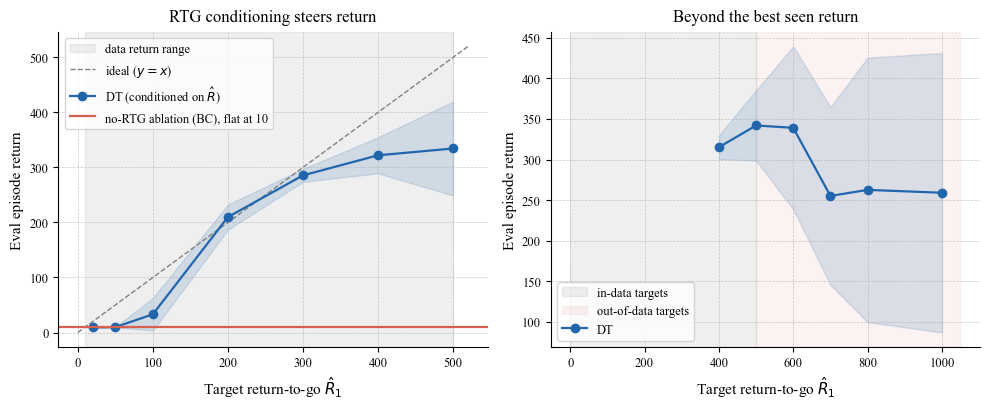

Saved fig1_rtg_conditioning.pdf


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

ax = axes[0]
ax.axvspan(data_min, data_max, color=GRAY, alpha=0.12, label='data return range')
ax.plot([0, 520], [0, 520], color=GRAY, linestyle='--', linewidth=1.0, label='ideal ($y=x$)')
mu, sd = dt_curve.mean(0), dt_curve.std(0)
ax.plot(TARGETS, mu, color=BLUE, marker='o', linewidth=1.6, label='DT (conditioned on $\\hat{R}$)')
ax.fill_between(TARGETS, mu - sd, mu + sd, color=BLUE, alpha=0.15)
bc_mu = bc_curve.mean()
ax.axhline(bc_mu, color=RED, linewidth=1.6,
           label=f'no-RTG ablation (BC), flat at {bc_mu:.0f}')
style_axes(ax)
ax.set_xlabel('Target return-to-go $\\hat{R}_1$')
ax.set_ylabel('Eval episode return')
ax.set_title('RTG conditioning steers return', pad=8)
ax.legend(loc='upper left')

ax = axes[1]
mu, sd = ood_curve.mean(0), ood_curve.std(0)
ax.axvspan(0, data_max, color=GRAY, alpha=0.12, label='in-data targets')
ax.axvspan(data_max, 1050, color=RED, alpha=0.08, label='out-of-data targets')
ax.plot(OOD_TARGETS, mu, color=BLUE, marker='o', linewidth=1.6, label='DT')
ax.fill_between(OOD_TARGETS, mu - sd, mu + sd, color=BLUE, alpha=0.15)
style_axes(ax)
ax.set_xlabel('Target return-to-go $\\hat{R}_1$')
ax.set_ylabel('Eval episode return')
ax.set_title('Beyond the best seen return', pad=8)
ax.legend(loc='lower left')

fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig1_rtg_conditioning.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_rtg_conditioning.pdf')

---
## Figure 2 — 数据质量天花板：回放，不是改进

三档数据（random / medium / expert，与第 9 章同一采集配方）分别训练 DT 与 BC（同结构、无 RTG），评估 DT 时把目标设在数据的最优回报。柱状对比：DT 与 BC 的评估回报都贴着**数据水平**（random：22 → DT 44 / BC 10；medium：211 → 267 / 262；expert：361 → 352 / 347），谁也没有超过数据最优——序列建模会「回放」数据里的行为，不会「改进」它。expert 档有一个种子的 DQN 采集策略停在 102 分，把三种子数据均值拉到 361，也让 DT/BC 的误差条变得巨大——**误差条本身就是天花板的证据：模型质量逐种子跟随数据质量**。对比第 9 章：CQL/IQL 在同一配方的 medium 数据上恢复到 BC 之上；DT 的天花板就是数据本身（3 seeds，误差条 $\pm 1\sigma$）。

=== Experiment 2: data quality ceiling (random / medium / expert) ===


  random : data   22.2 | DT   44.4 ±  27.2 | BC   10.0 ±   0.3


  medium : data  211.1 | DT  266.8 ±  12.2 | BC  262.0 ±  27.0


  expert : data  361.4 | DT  351.6 ± 173.2 | BC  347.0 ± 172.7


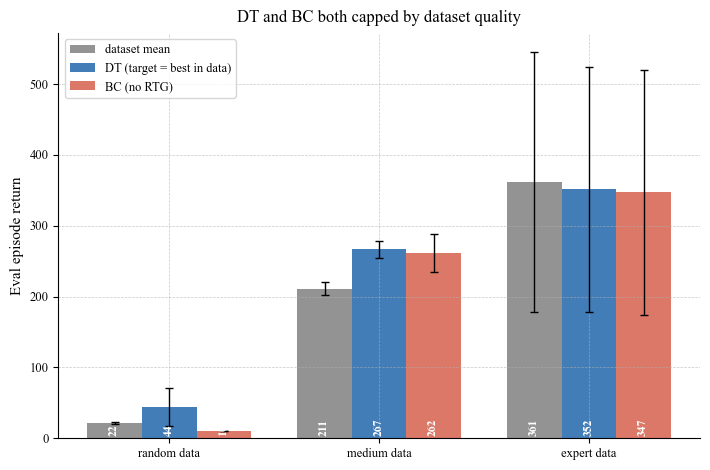

Saved fig2_data_quality.pdf


In [8]:
print('=== Experiment 2: data quality ceiling (random / medium / expert) ===')
results = {}
for name in ('random', 'medium', 'expert'):
    per_seed = {'dt': [], 'bc': [], 'data': []}
    for seed in SEEDS:
        d = runs[seed]['data'][name]
        target = max(sum(e['rewards']) for e in d)
        model, win = train_dt(d, 2, seed + 200)
        per_seed['dt'].append(evaluate_dt(model, win, 2, target, seed=seed + 300)[0])
        bmodel, bwin = train_dt(d, 2, seed + 400, use_rtg=False)
        per_seed['bc'].append(evaluate_dt(bmodel, bwin, 2, target,
                                          use_rtg=False, seed=seed + 500)[0])
        per_seed['data'].append(np.mean([sum(e['rewards']) for e in d]))
    results[name] = {k: np.array(v) for k, v in per_seed.items()}
    print(f"  {name:<7s}: data {results[name]['data'].mean():6.1f} | "
          f"DT {results[name]['dt'].mean():6.1f} ± {results[name]['dt'].std():5.1f} | "
          f"BC {results[name]['bc'].mean():6.1f} ± {results[name]['bc'].std():5.1f}")

fig, ax = plt.subplots(figsize=FIGSIZE)
names = ('random', 'medium', 'expert')
x = np.arange(len(names)); w = 0.26
for off, key, color, label in [(-w, 'data', GRAY, 'dataset mean'),
                               (0.0, 'dt',  BLUE, 'DT (target = best in data)'),
                               (w,   'bc',  RED,  'BC (no RTG)')]:
    mu = [results[n][key].mean() for n in names]
    sd = [results[n][key].std() for n in names]
    bars = ax.bar(x + off, mu, w, color=color, alpha=0.85, label=label,
                  yerr=sd, capsize=3, error_kw=dict(lw=1))
    for b, m in zip(bars, mu):
        ax.text(b.get_x() + b.get_width() / 2, 8, f'{m:.0f}', ha='center',
                fontsize=8.5, rotation=90, color='white', fontweight='bold')
style_axes(ax)
ax.set_xticks(x); ax.set_xticklabels(['random data', 'medium data', 'expert data'])
ax.set_ylabel('Eval episode return')
ax.set_title('DT and BC both capped by dataset quality', pad=8)
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig2_data_quality.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_data_quality.pdf')

---
## Figure 3 — 拼接失败：检索见过的轨迹，不组合未见过的

确定性 8×8 格子世界，起点左下、终点右上，每步奖励 $-1$（最短路径 14 步）。数据 400 条轨迹，行为策略以 15% 概率故意绕路，并剔除所有短于 16 步的轨迹——**数据中最好的轨迹是 16 步，最优的 14 步路径从未整条出现**，但它需要的每一步转移都在数据里（三个种子均为 14/14，散布在不同轨迹中）。

左图：把目标长度从 30 扫到 14。DT 在 $\ge 22$ 的目标上正常兑现（目标与实际有数步的校准偏差）；目标 $\le 20$ 进入数据稀疏区后开始失效；条件在从未出现的 14 上，90 个评估回合中 60 个无法到达终点（均值被 60 步上限顶到 $\approx 47$）。表格型**离线 Q-learning 在同一份数据上拼出 14 步最优路径**（三个种子一致）——动态规划会跨轨迹组合转移，序列建模不会。右图：数据访问热力图与路径对比——Q-learning 的对角捷径由跨轨迹拼接而来，DT 在目标 14 下的实际轨迹偏离最优（3 seeds，mean $\pm$ std）。

In [6]:
print('=== Experiment 3: stitching in the gridworld ===')
gw_runs = {}
for seed in SEEDS:
    rng = np.random.default_rng(seed)
    episodes = [gw_gen_episode(rng) for _ in range(GW_EPISODES)]
    lens = [len(e['actions']) for e in episodes]
    print(f'  seed {seed}: {len(episodes)} eps | len mean {np.mean(lens):.1f} '
          f'| min {np.min(lens)} | max {np.max(lens)}')
    # 最优路径（先上后右）需要的转移是否都在数据里？
    have = {(int(e['states'][t]), int(e['actions'][t]))
            for e in episodes for t in range(len(e['actions']))}
    need, s = [], GW_START
    while s != GW_GOAL:
        row, _ = divmod(s, GW_SIZE)
        a = 0 if row > 0 else 3
        need.append((s, a))
        s, _, _ = gw_step(s, a)
    cover = sum(p in have for p in need)
    print(f'    optimal-path transitions in data: {cover}/{len(need)}')
    dt_data = gw_to_dt(episodes)
    model, win = train_dt(dt_data, 4, seed + 600, steps=8000)
    Q, qpath = gw_q_learning(episodes)
    gw_runs[seed] = {'episodes': episodes, 'dt': model, 'win': win, 'qpath': qpath}
    print(f'    Q-learning greedy path length: {len(qpath) - 1}')

GW_TARGETS = [30, 26, 24, 22, 20, 18, 17, 16, 15, 14]
gw_curve, gw_fails = [], []
for seed in SEEDS:
    r, w = gw_runs[seed]['dt'], gw_runs[seed]['win']
    rows = [gw_eval_dt(r, w, 4, t) for t in GW_TARGETS]
    gw_curve.append([x[0] for x in rows])
    gw_fails.append([x[2] for x in rows])
gw_curve = np.array(gw_curve)
gw_fails = np.array(gw_fails)
for i, t in enumerate(GW_TARGETS):
    print(f'  target len {t}: DT {gw_curve[:, i].mean():5.1f} ± {gw_curve[:, i].std():4.1f} '
          f'| failures {gw_fails[:, i].sum()}/{30 * len(SEEDS)}')

qlen = len(gw_runs[SEEDS[0]]['qpath']) - 1
best_seen = min(len(e['actions']) for e in gw_runs[SEEDS[0]]['episodes'])
print(f'Q-learning path: {qlen} steps | best seen in data: {best_seen} steps')

=== Experiment 3: stitching in the gridworld ===
  seed 42: 400 eps | len mean 24.9 | min 16 | max 51
    optimal-path transitions in data: 14/14


    Q-learning greedy path length: 14
  seed 43: 400 eps | len mean 24.9 | min 16 | max 57
    optimal-path transitions in data: 14/14


    Q-learning greedy path length: 14
  seed 44: 400 eps | len mean 25.1 | min 16 | max 58
    optimal-path transitions in data: 14/14


    Q-learning greedy path length: 14


  target len 30: DT  23.3 ±  2.1 | failures 0/90
  target len 26: DT  19.3 ±  2.1 | failures 0/90
  target len 24: DT  17.3 ±  2.1 | failures 0/90
  target len 22: DT  16.0 ±  0.8 | failures 0/90
  target len 20: DT  33.3 ± 19.1 | failures 30/90
  target len 18: DT  32.7 ± 19.8 | failures 30/90
  target len 17: DT  47.7 ± 17.4 | failures 60/90
  target len 16: DT  47.7 ± 17.4 | failures 60/90
  target len 15: DT  47.3 ± 17.9 | failures 60/90
  target len 14: DT  47.3 ± 17.9 | failures 60/90
Q-learning path: 14 steps | best seen in data: 16 steps


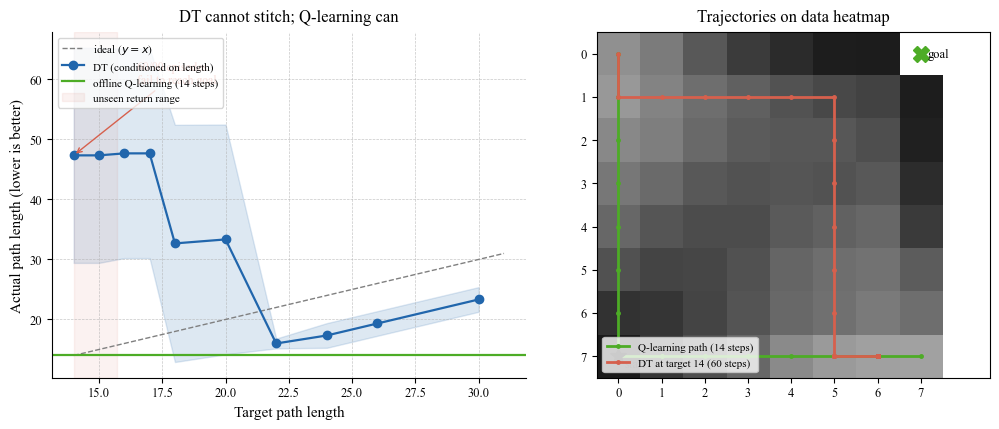

Saved fig3_stitching.pdf


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))

ax = axes[0]
ax.plot([14, 31], [14, 31], color=GRAY, linestyle='--', linewidth=1.0, label='ideal ($y=x$)')
mu, sd = gw_curve.mean(0), gw_curve.std(0)
ax.plot(GW_TARGETS, mu, color=BLUE, marker='o', linewidth=1.6, label='DT (conditioned on length)')
ax.fill_between(GW_TARGETS, mu - sd, mu + sd, color=BLUE, alpha=0.15)
ax.axhline(qlen, color=GREEN, linewidth=1.6, label=f'offline Q-learning ({qlen} steps)')
ax.axvspan(14, best_seen - 0.3, color=RED, alpha=0.08, label='unseen return range')
ax.annotate(f'{gw_fails[:, -1].sum()}/{30 * len(SEEDS)} episodes\nfail to reach goal',
            xy=(14, mu[-1]), xytext=(16.5, mu[-1] + 12), fontsize=8.5, color=RED,
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.0))
style_axes(ax)
ax.set_xlabel('Target path length')
ax.set_ylabel('Actual path length (lower is better)')
ax.set_title('DT cannot stitch; Q-learning can', pad=8)
ax.legend(loc='upper left', fontsize=8)

ax = axes[1]
visits = np.zeros((GW_SIZE, GW_SIZE))
for e in gw_runs[SEEDS[0]]['episodes']:
    for s in e['states']:
        visits[s // GW_SIZE, s % GW_SIZE] += 1
ax.imshow(np.log1p(visits), origin='upper', cmap='Greys', alpha=0.9)

def draw_path(ax, path, color, label, lw=2.0, ls='-'):
    rows = [7 - s // GW_SIZE for s in path]
    cols = [s % GW_SIZE for s in path]
    ax.plot(cols, rows, color=color, linewidth=lw, linestyle=ls, label=label,
            marker='o', markersize=2.5)

draw_path(ax, gw_runs[SEEDS[0]]['qpath'], GREEN, f'Q-learning path ({qlen} steps)')


def gw_dt_path(model, win, target_len, cap=60):
    s, rtg, prev_a = GW_START, -float(target_len), 4
    ctx_s, ctx_pa, ctx_rtg = [], [], []
    path = [s]
    with torch.no_grad():
        for _ in range(cap):
            ctx_s.append(np.array([(s // GW_SIZE) / 7.0, (s % GW_SIZE) / 7.0], np.float32))
            ctx_pa.append(prev_a)
            ctx_rtg.append(rtg / win.rtg_scale)
            K = win.K
            L = len(ctx_s)
            take = min(L, K)
            start = K - take
            rtgW = torch.zeros((1, K), device=DEVICE)
            sW = torch.zeros((1, K, 2), device=DEVICE)
            paW = torch.full((1, K), 4, dtype=torch.long, device=DEVICE)
            mW = torch.zeros((1, K), dtype=torch.bool, device=DEVICE)
            rtgW[0, start:] = torch.tensor(ctx_rtg[-take:], device=DEVICE)
            sW[0, start:] = torch.tensor(np.array(ctx_s[-take:]), device=DEVICE)
            paW[0, start:] = torch.tensor(ctx_pa[-take:], device=DEVICE)
            mW[0, start:] = True
            a = int(model(rtgW, sW, paW, mW)[0, -1].argmax())
            s, r, done = gw_step(s, a)
            rtg -= r
            prev_a = a
            path.append(s)
            if done:
                break
    return path

dt_path = gw_dt_path(gw_runs[SEEDS[0]]['dt'], gw_runs[SEEDS[0]]['win'], 14)
draw_path(ax, dt_path, RED, f'DT at target 14 ({len(dt_path) - 1} steps)')
ax.plot(0, 7, marker='*', color='black', markersize=12, linestyle='None')
ax.plot(7, 0, marker='X', color=GREEN, markersize=11, linestyle='None')
ax.text(7.15, 0, 'goal', fontsize=9, va='center')
ax.text(0.15, 7.25, 'start', fontsize=9)
ax.set_xticks(range(GW_SIZE))
ax.set_yticks(range(GW_SIZE))
ax.set_xlim(-0.5, 8.6)
ax.set_ylim(7.5, -0.5)
ax.set_title('Trajectories on data heatmap', pad=8)
ax.legend(loc='lower left', fontsize=8)

fig.tight_layout()
fig.savefig(f'{OUTDIR}/fig3_stitching.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_stitching.pdf')

## 小结

- **RTG 条件化是「指挥棒」**：期望回报作为输入，让一个纯监督的序列模型获得了按目标分级的行为——但指挥棒只在数据覆盖区内有效，目标超出数据最优就失效（Figure 1）；
- **数据质量天花板**：random/medium/expert 三档数据上，DT 与 BC 的回报都钉在数据水平——序列建模回放数据，不改进数据（Figure 2）；
- **拼接失败**：最优路径的转移都在数据里、只是从未出现在同一条轨迹中——Q-learning 能跨轨迹组合（stitching），DT 不能：它检索见过的轨迹模式，不规划未见过的组合（Figure 3）；
- **与第 9 章合起来**：CQL/IQL 用悲观化把价值外推到数据之外，DT 干脆不外推——两种对「离线数据」的哲学。数据接近最优时 DT 简单稳定（像 SFT）；数据次优且需要超越时，价值方法仍不可替代；
- **通往 LLM 三部曲**：本章的 Transformer 与下一章起 RLHF/DPO/GRPO 用的语言模型是同一个物种——「序列建模 + 条件生成」是后训练一切方法的载体，差别只在条件是什么、目标怎么来。